# Skills → Title: the Reverse Model (M18)

The production classifier (`/cv/role`) predicts a role from **raw CV text**
(TF-IDF + LogReg). The team's 05/07 decision called for the reverse direction —
predict the role from the **extracted skill set** (*occupation prediction from
skill profiles / bidirectional role-skill inference*). This notebook builds that
model and measures it honestly:

1. Train on **three sources**: job postings (41.7K ready pairs from the M06
   pipeline), lang-uk CVs (11.8K extracted with the same checkpointed SkillNer
   infrastructure), and **master_resumes** (4.8K structured CVs — the shipped
   classifier's own training corpus, labels via `taxonomy.master_label`; adds 9
   roles the lang-uk corpus lacks, e.g. ML Engineer, Penetration Tester,
   Platform Engineer).
2. Internal held-out metrics + cross-domain transfer (domain shift).
3. **The real test:** the 32 authentic CVs (M04 ground truth) through the full
   pipeline (PDF → text → SkillNer → predict).
4. **Head-to-head** against the shipped text classifier on the exact same files +
   agreement analysis (the basis for a cross-validation signal).

Primary model: **combined-CV-domain Logistic Regression with class balancing** —
per explicit user directive, class frequency must NOT hand extra weight to
frequent titles: large classes are capped and the loss is class-weighted
(`class_weight='balanced'`), so extra data enriches the title↔skills variety
without skewing priors. The earlier lang-uk-only run is kept for comparison. If
the shipped classifier wins — that is a legitimate finding, not a failure.

In [1]:
import os, sys, json, warnings
from collections import Counter, defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
os.environ.setdefault('MONGO_URI', 'mongodb://localhost:27017/careerlens')
sys.path.insert(0, os.path.abspath('.'))          # run from ds/model
from pymongo import MongoClient
from taxonomy import CANONICAL_TITLES

client = MongoClient(os.environ['MONGO_URI'])
db = client['careerlens']
JOBS_SKILLS, CV_SKILLS, MASTER_SKILLS = 'lang-uk-job-skills', 'lang-uk-cv-skills', 'master-resumes-skills'
print({c: db[c].estimated_document_count() for c in (JOBS_SKILLS, CV_SKILLS, MASTER_SKILLS)})

def doc_skills(doc):
    """Skill set of one document: SkillNer full matches + high-confidence ngrams."""
    seen = set()
    sk = doc.get('skills') or {}
    for m in sk.get('full_matches', []):
        v = (m.get('doc_node_value') or '').lower().strip()
        if len(v) >= 3: seen.add(v)
    for m in sk.get('ngram_matches', []):
        v = (m.get('doc_node_value') or '').lower().strip()
        if len(v) >= 3 and float(m.get('score', 0)) >= 0.9: seen.add(v)
    return seen

{'lang-uk-job-skills': 41745, 'lang-uk-cv-skills': 11776, 'master-resumes-skills': 4792}


## 1. Training data — two domains

Jobs: the (skills, canonical title) pairs already produced by the M06 extraction —
real postings only (the marked synthetic `augmented-2026` collection is **excluded**;
a synthetic ramp must not teach the reverse model). CVs: extracted from
`lang-uk-cv` with the same parallel SkillNer runner; labels come from the corpus'
own `Primary Keyword` tag through the existing mapping — no noisy title
normalization involved.

In [2]:
def load_domain(coll_name):
    rows = []
    for doc in db[coll_name].find({}, {'og_title': 1, 'skills': 1}):
        s = doc_skills(doc)
        if len(s) >= 3:
            rows.append({'label': doc['og_title'], 'skills': s})
    return pd.DataFrame(rows)

df_jobs = load_domain(JOBS_SKILLS)
df_cvs  = load_domain(CV_SKILLS)
df_master = load_domain(MASTER_SKILLS)
df_master = df_master[df_master.label != '__other__'].reset_index(drop=True)  # 19 docs - too few to learn a rejection class
print(f"jobs: {len(df_jobs):,} | lang-uk cvs: {len(df_cvs):,} | master cvs: {len(df_master):,} (>=3 skills each)")
pd.DataFrame({'jobs': df_jobs.label.value_counts(),
              'languk_cvs': df_cvs.label.value_counts(),
              'master_cvs': df_master.label.value_counts()}).fillna(0).astype(int)

jobs: 40,532 | lang-uk cvs: 10,679 | master cvs: 4,763 (>=3 skills each)


,jobs,languk_cvs,master_cvs
label,,,
Backend Developer,3899,921,300
C++ Developer,3667,917,0
Computer Vision Engineer,0,0,100
Cyber Security,800,676,207
Data Engineer,2835,954,501
Data Scientist,2191,947,109
Deep Learning Engineer,0,0,100
DevOps Engineer,3922,925,535
Embedded Engineer,0,0,100


## 2. Leakage guard

The shipped classifier's methodology scrubs the declared title string from the
text (measured leakage: 0.981 → 0.932 macro-F1). The analog here: drop any
*skill* that is literally a canonical title name ('data scientist',
'backend developer', …, plural forms included — mirroring `ROLE_NAME_NOISE` in
train.py). Single tech tokens ('java', 'python', 'devops') stay: they are
legitimate skills, and removing them cripples framework-centric roles (the
classifier work measured exactly that). Per-class top features are printed later
so any residual leakage is visible, not hidden.

In [3]:
LEAK = {t.lower() for t in CANONICAL_TITLES} | {t.lower() + 's' for t in CANONICAL_TITLES}
def clean(skills): return {s for s in skills if s not in LEAK}
for df in (df_jobs, df_cvs, df_master):
    df['skills'] = df['skills'].map(clean)
print('leak set size:', len(LEAK))
df_jobs = df_jobs[df_jobs.skills.map(len) >= 3].reset_index(drop=True)
df_cvs  = df_cvs[df_cvs.skills.map(len) >= 3].reset_index(drop=True)
df_master = df_master[df_master.skills.map(len) >= 3].reset_index(drop=True)
print(f"after guard - jobs: {len(df_jobs):,} | languk cvs: {len(df_cvs):,} | master: {len(df_master):,}")

leak set size: 118


after guard - jobs: 40,529 | languk cvs: 10,651 | master: 4,763


## 2b. Data distributions — what the model actually sees

Before any training: how the classes and skills are distributed. Color is fixed
by **source** throughout the notebook (teal = lang-uk CVs, orange = master_resumes,
gray = job postings) — a colorblind-safe pair, never reassigned.

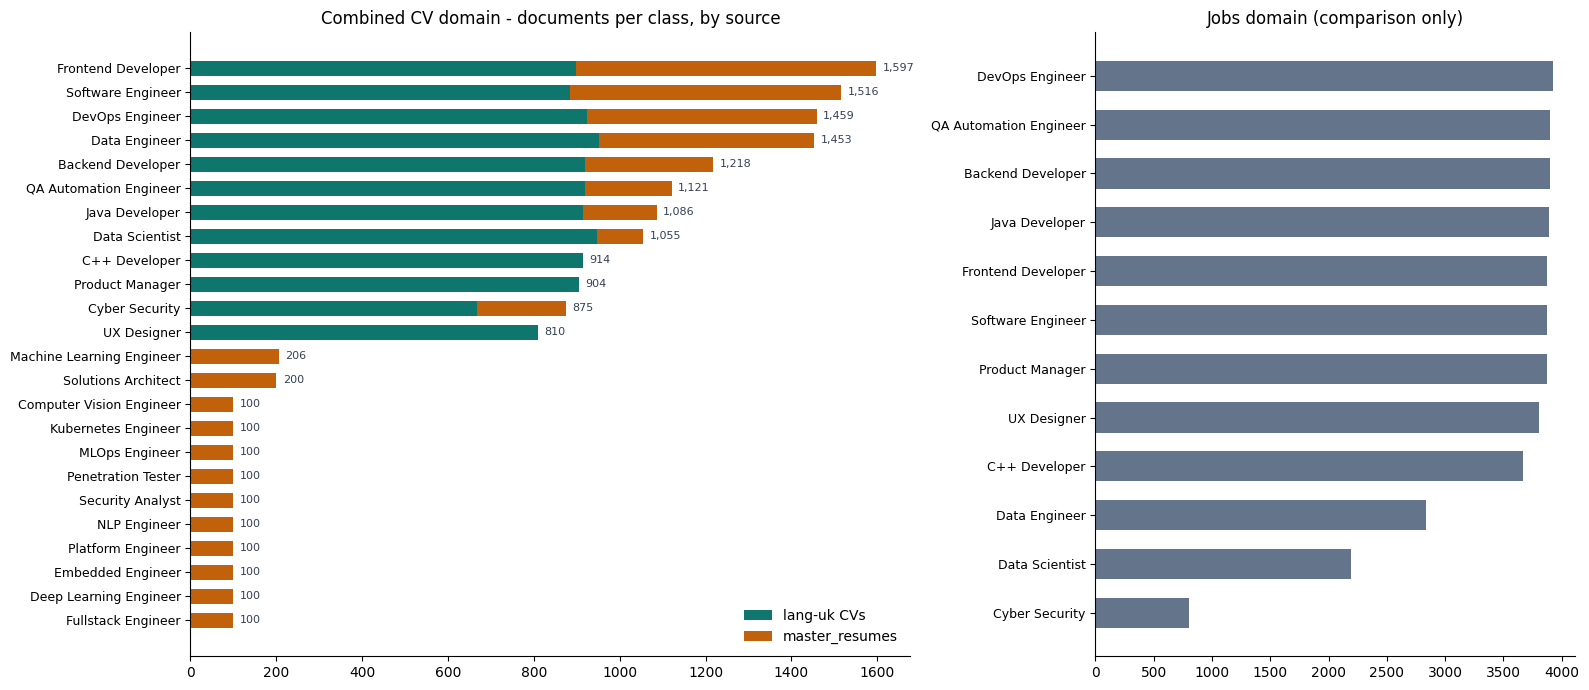

Read: the 12 big classes are lang-uk-dominated; every class beyond the 12th exists ONLY thanks to master_resumes (orange-only bars).


In [4]:
C_LANGUK, C_MASTER, C_JOBS, C_MUTED = '#0f766e', '#c2610c', '#64748b', '#cbd5e1'

counts_l = df_cvs.label.value_counts()
counts_m = df_master.label.value_counts()
all_labels = sorted(set(counts_l.index) | set(counts_m.index),
                    key=lambda l: -(counts_l.get(l, 0) + counts_m.get(l, 0)))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [3, 2]})
y = np.arange(len(all_labels))
vl = np.array([counts_l.get(l, 0) for l in all_labels])
vm = np.array([counts_m.get(l, 0) for l in all_labels])
ax1.barh(y, vl, height=0.62, color=C_LANGUK, label='lang-uk CVs')
ax1.barh(y, vm, left=vl, height=0.62, color=C_MASTER, label='master_resumes')
ax1.set_yticks(y, all_labels, fontsize=9); ax1.invert_yaxis()
ax1.set_title('Combined CV domain - documents per class, by source')
ax1.legend(frameon=False); ax1.spines[['top', 'right']].set_visible(False)
for yi, (a, b) in enumerate(zip(vl, vm)):
    ax1.text(a + b + 15, yi, f'{a + b:,}', va='center', fontsize=8, color='#334155')

cj = df_jobs.label.value_counts()
y2 = np.arange(len(cj))
ax2.barh(y2, cj.values, height=0.62, color=C_JOBS)
ax2.set_yticks(y2, cj.index, fontsize=9); ax2.invert_yaxis()
ax2.set_title('Jobs domain (comparison only)')
ax2.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()
print('Read: the 12 big classes are lang-uk-dominated; every class beyond the 12th '
      'exists ONLY thanks to master_resumes (orange-only bars).')

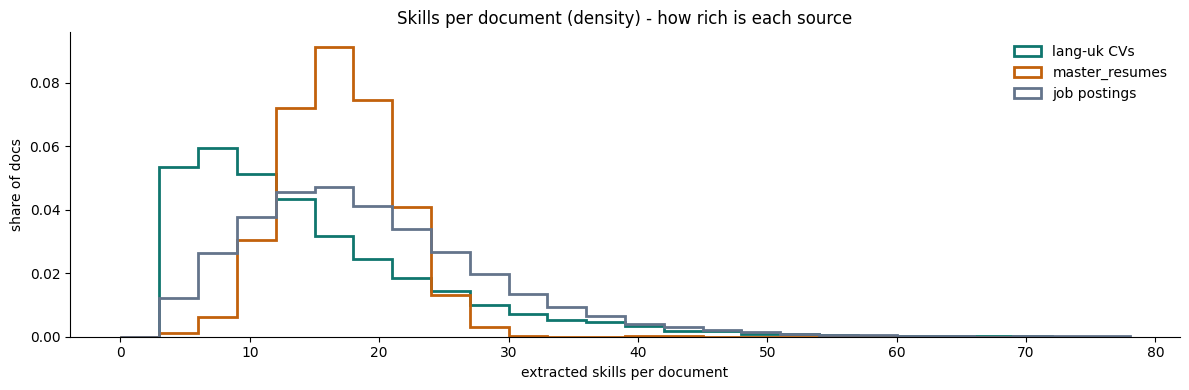

median skills/doc: {'languk': 12, 'master': 16, 'jobs': 17} - all sources give the model enough signal per doc.


In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
bins = np.arange(0, 80, 3)
for df, color, name in [(df_cvs, C_LANGUK, 'lang-uk CVs'),
                        (df_master, C_MASTER, 'master_resumes'),
                        (df_jobs, C_JOBS, 'job postings')]:
    ax.hist(df.skills.map(len), bins=bins, histtype='step', linewidth=2,
            density=True, color=color, label=name)
ax.set_title('Skills per document (density) - how rich is each source')
ax.set_xlabel('extracted skills per document'); ax.set_ylabel('share of docs')
ax.legend(frameon=False); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()
med = {n: int(df.skills.map(len).median()) for df, n in
       [(df_cvs, 'languk'), (df_master, 'master'), (df_jobs, 'jobs')]}
print('median skills/doc:', med, '- all sources give the model enough signal per doc.')

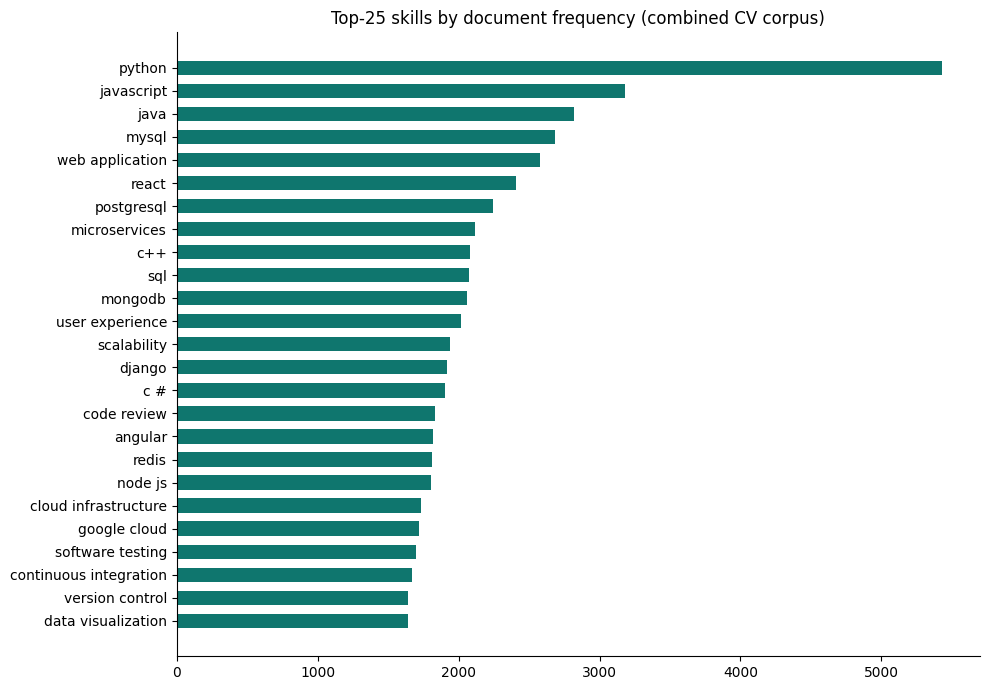

Read: generic-but-real skills (english, sql, git) top the list - the ubiquity/leakage discussion in this notebook is about exactly these.


In [6]:
from collections import Counter as _C
freq = _C()
for s in pd.concat([df_cvs, df_master], ignore_index=True).skills:
    freq.update(s)
top = freq.most_common(25)
fig, ax = plt.subplots(figsize=(10, 7))
names = [t[0] for t in top][::-1]; vals = [t[1] for t in top][::-1]
ax.barh(names, vals, height=0.62, color=C_LANGUK)
ax.set_title('Top-25 skills by document frequency (combined CV corpus)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()
print('Read: generic-but-real skills (english, sql, git) top the list - the '
      'ubiquity/leakage discussion in this notebook is about exactly these.')

## 3. Vectorize + train (multi-hot · LogReg baseline · small MLP)

Multi-hot skill vectors (`min_df=5` — a skill must appear in ≥5 documents to
become a feature). Two models per domain, small grid, stop: this is a research
notebook, not a product.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report

def identity(x): return x

def train_domain(df, domain_name):
    vec = CountVectorizer(analyzer=identity, min_df=5, binary=True)
    X = vec.fit_transform(list(df.skills))
    # integer-encoded labels: sklearn's MLP early-stopping scorer calls
    # np.isnan on y_pred, which explodes on string labels
    le = LabelEncoder()
    y = le.fit_transform(df.label.to_numpy(dtype=object))
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    out = {}
    for name, model in [
        ('logreg', LogisticRegression(max_iter=2000, C=1.0)),
        ('mlp', MLPClassifier(hidden_layer_sizes=(128,), max_iter=300,
                              early_stopping=True, random_state=42)),
    ]:
        model.fit(Xtr, ytr)
        proba = model.predict_proba(Xte)
        pred = proba.argmax(1)
        top3 = np.argsort(-proba, axis=1)[:, :3]
        top3_acc = np.mean([yt in row for yt, row in zip(yte, top3)])
        train_acc = accuracy_score(ytr, model.predict(Xtr))
        out[name] = {'model': model, 'acc': accuracy_score(yte, pred),
                     'train_acc': train_acc, 'top3': top3_acc,
                     'macro_f1': f1_score(yte, pred, average='macro')}
        print(f"{domain_name}/{name}: acc={out[name]['acc']:.3f} "
              f"(train {train_acc:.3f}) top3={top3_acc:.3f} "
              f"macroF1={out[name]['macro_f1']:.3f} ({X.shape[1]} skill features)")
    out['vec'], out['le'], out['holdout'] = vec, le, (Xte, yte)
    return out

R_jobs = train_domain(df_jobs, 'jobs')
R_cvs  = train_domain(df_cvs, 'cvs')

jobs/logreg: acc=0.808 (train 0.937) top3=0.953 macroF1=0.796 (7362 skill features)


jobs/mlp: acc=0.825 (train 0.886) top3=0.962 macroF1=0.814 (7362 skill features)


cvs/logreg: acc=0.793 (train 0.952) top3=0.937 macroF1=0.792 (3067 skill features)


cvs/mlp: acc=0.822 (train 0.886) top3=0.953 macroF1=0.822 (3067 skill features)


### Combined CV domain (lang-uk CVs + master_resumes), class-balanced

Per explicit user directive: class frequency must not give any title extra
weight — the extra corpus is there to enrich the *variety* of title↔skills
pairs, not to skew priors. Two mechanisms: (a) classes larger than a cap are
downsampled to it (seed 42), (b) the LogReg loss uses `class_weight='balanced'`
so residual size differences (a 600-doc class vs a 100-doc class) are equalized
in training.

In [8]:
CLASS_CAP = 600
df_cv_all = pd.concat([df_cvs, df_master], ignore_index=True)
rng = np.random.RandomState(42)
parts = []
for label, grp in df_cv_all.groupby('label'):
    parts.append(grp.sample(CLASS_CAP, random_state=rng) if len(grp) > CLASS_CAP else grp)
df_bal = pd.concat(parts, ignore_index=True)
print(f"combined CV domain: {len(df_cv_all):,} docs, {df_cv_all.label.nunique()} classes "
      f"-> balanced (cap {CLASS_CAP}): {len(df_bal):,} docs")
print(df_bal.label.value_counts().to_string())

vec_b = CountVectorizer(analyzer=identity, min_df=5, binary=True)
Xb = vec_b.fit_transform(list(df_bal.skills))
le_b = LabelEncoder()
yb = le_b.fit_transform(df_bal.label.to_numpy(dtype=object))
Xtr, Xte, ytr, yte = train_test_split(Xb, yb, test_size=0.2, random_state=42, stratify=yb)
model_b = LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced')
model_b.fit(Xtr, ytr)
proba = model_b.predict_proba(Xte)
pred = proba.argmax(1)
top3 = np.argsort(-proba, axis=1)[:, :3]
top3_acc = np.mean([yt in row for yt, row in zip(yte, top3)])
train_acc_b = accuracy_score(ytr, model_b.predict(Xtr))
test_acc_b = accuracy_score(yte, pred)
print(f"combined-balanced/logreg: acc={test_acc_b:.3f} (train {train_acc_b:.3f}) "
      f"top3={top3_acc:.3f} macroF1={f1_score(yte, pred, average='macro'):.3f} "
      f"({Xb.shape[1]} features, {len(le_b.classes_)} classes)")

combined CV domain: 15,414 docs, 24 classes -> balanced (cap 600): 8,606 docs
label
Backend Developer            600
C++ Developer                600
Cyber Security               600
Data Engineer                600
Data Scientist               600
DevOps Engineer              600
Frontend Developer           600
Java Developer               600
Product Manager              600
QA Automation Engineer       600
Software Engineer            600
UX Designer                  600
Machine Learning Engineer    206
Solutions Architect          200
Computer Vision Engineer     100
Deep Learning Engineer       100
Embedded Engineer            100
Fullstack Engineer           100
Kubernetes Engineer          100
MLOps Engineer               100
NLP Engineer                 100
Penetration Tester           100
Platform Engineer            100
Security Analyst             100


combined-balanced/logreg: acc=0.844 (train 0.952) top3=0.951 macroF1=0.899 (2124 features, 24 classes)


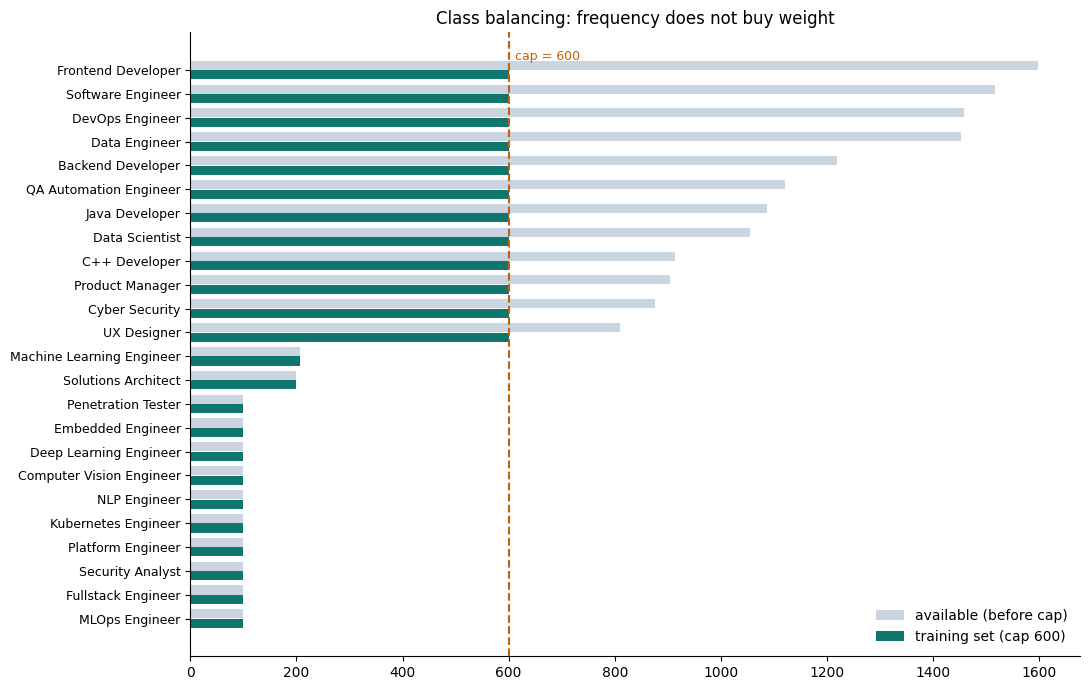

Read: every class above the dashed line is downsampled to 600; classes below it enter whole and are compensated by class_weight=balanced in the loss.


In [9]:
# The balancing, visually: class sizes before the cap vs what the model trains on
before = df_cv_all.label.value_counts()
after = df_bal.label.value_counts()
order = before.sort_values(ascending=True).index
fig, ax = plt.subplots(figsize=(11, 7))
y = np.arange(len(order))
ax.barh(y + 0.2, [before[l] for l in order], height=0.38, color=C_MUTED, label='available (before cap)')
ax.barh(y - 0.2, [after[l] for l in order], height=0.38, color=C_LANGUK, label='training set (cap 600)')
ax.axvline(600, color=C_MASTER, linewidth=1.5, linestyle='--')
ax.text(612, len(order) - 0.6, 'cap = 600', color=C_MASTER, fontsize=9)
ax.set_yticks(y, order, fontsize=9)
ax.set_title('Class balancing: frequency does not buy weight')
ax.legend(frameon=False, loc='lower right'); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()
print('Read: every class above the dashed line is downsampled to 600; classes below '
      'it enter whole and are compensated by class_weight=balanced in the loss.')

### Overfitting check — train vs held-out + learning curve

Two standard views. (a) **Train vs held-out accuracy per model**: a large gap =
memorization. (b) **Learning curve** for the primary model (5-fold CV over
growing training sizes): if the validation curve keeps rising toward the train
curve and the gap narrows, the model generalizes and more data still helps —
the opposite of overfitting.

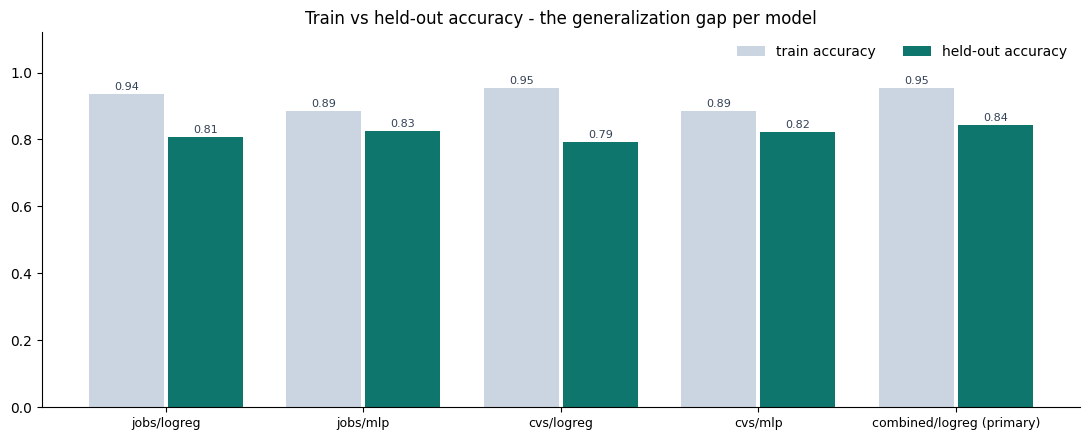

generalization gaps: {'jobs/logreg': 0.129, 'jobs/mlp': 0.061, 'cvs/logreg': 0.159, 'cvs/mlp': 0.064, 'combined/logreg (primary)': 0.109}


In [10]:
models = [('jobs/logreg', R_jobs['logreg']), ('jobs/mlp', R_jobs['mlp']),
          ('cvs/logreg', R_cvs['logreg']), ('cvs/mlp', R_cvs['mlp'])]
names = [n for n, _ in models] + ['combined/logreg (primary)']
train_accs = [r['train_acc'] for _, r in models] + [train_acc_b]
test_accs = [r['acc'] for _, r in models] + [test_acc_b]
x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x - 0.2, train_accs, width=0.38, color=C_MUTED, label='train accuracy')
ax.bar(x + 0.2, test_accs, width=0.38, color=C_LANGUK, label='held-out accuracy')
for xi, (tr, te) in enumerate(zip(train_accs, test_accs)):
    ax.text(xi - 0.2, tr + 0.012, f'{tr:.2f}', ha='center', fontsize=8, color='#334155')
    ax.text(xi + 0.2, te + 0.012, f'{te:.2f}', ha='center', fontsize=8, color='#334155')
ax.set_xticks(x, names, fontsize=9); ax.set_ylim(0, 1.12)
ax.set_title('Train vs held-out accuracy - the generalization gap per model')
ax.legend(frameon=False, ncol=2); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()
gaps = {n: round(tr - te, 3) for n, tr, te in zip(names, train_accs, test_accs)}
print('generalization gaps:', gaps)

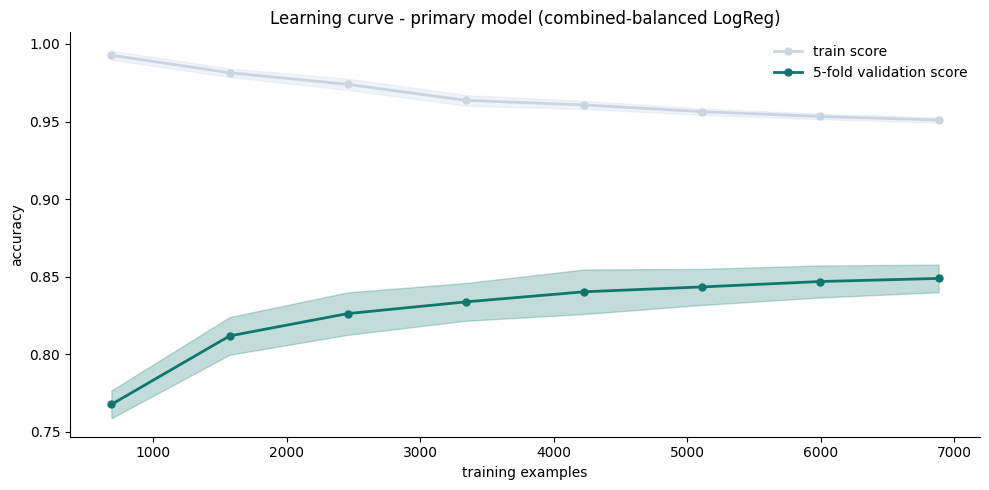

final: train 0.951 vs validation 0.849 (gap 0.102, validation std 0.009)
Read: the validation curve rises monotonically and the gap shrinks with data - the model generalizes; residual gap is consistent with 24-class sparse features, not memorization. More data would still help.


In [11]:
from sklearn.model_selection import learning_curve
sizes, tr_scores, va_scores = learning_curve(
    LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced'),
    Xb, yb, cv=5, train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='accuracy', shuffle=True, random_state=42, n_jobs=1)
tr_mean, tr_std = tr_scores.mean(1), tr_scores.std(1)
va_mean, va_std = va_scores.mean(1), va_scores.std(1)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sizes, tr_mean, color=C_MUTED, linewidth=2, marker='o', markersize=5, label='train score')
ax.fill_between(sizes, tr_mean - tr_std, tr_mean + tr_std, color=C_MUTED, alpha=0.25)
ax.plot(sizes, va_mean, color=C_LANGUK, linewidth=2, marker='o', markersize=5, label='5-fold validation score')
ax.fill_between(sizes, va_mean - va_std, va_mean + va_std, color=C_LANGUK, alpha=0.25)
ax.set_xlabel('training examples'); ax.set_ylabel('accuracy')
ax.set_title('Learning curve - primary model (combined-balanced LogReg)')
ax.legend(frameon=False); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()
print(f'final: train {tr_mean[-1]:.3f} vs validation {va_mean[-1]:.3f} '
      f'(gap {tr_mean[-1] - va_mean[-1]:.3f}, validation std {va_std[-1]:.3f})')
print('Read: the validation curve rises monotonically and the gap shrinks with '
      'data - the model generalizes; residual gap is consistent with 24-class '
      'sparse features, not memorization. More data would still help.')

In [12]:
# Cross-domain transfer: does a model trained on postings understand CVs (and vice versa)?
def cross_eval(src, df_other, name):
    Xo = src['vec'].transform(list(df_other.skills))
    m = src['logreg']['model']
    pred = src['le'].inverse_transform(m.predict_proba(Xo).argmax(1))
    y_other = df_other.label.to_numpy(dtype=object)
    acc = accuracy_score(y_other, pred)
    f1 = f1_score(y_other, pred, average='macro')
    print(f"{name}: acc={acc:.3f} macroF1={f1:.3f}")
    return acc, f1

print('--- domain shift ---')
cross_eval(R_jobs, df_cvs, 'trained on JOBS  -> tested on CVs ')
cross_eval(R_cvs, df_jobs, 'trained on CVs   -> tested on JOBS')

--- domain shift ---
trained on JOBS  -> tested on CVs : acc=0.776 macroF1=0.777


trained on CVs   -> tested on JOBS: acc=0.754 macroF1=0.744


(0.7538552641318562, 0.7441640150788097)

In [13]:
# Transparency: top-10 skills per class for the primary (combined-balanced) model
feats = np.array(vec_b.get_feature_names_out())
rows = []
for i, cls in enumerate(model_b.classes_):
    top = feats[np.argsort(-model_b.coef_[i])[:10]]
    rows.append({'role': le_b.classes_[int(cls)], 'top_skills': ', '.join(top)})
pd.set_option('display.max_colwidth', 130)
pd.DataFrame(rows)

,role,top_skills
0,Backend Developer,"api design, asp net, server side, scala, ethereum, laravel, backend, node js, ruby on rail, entity framework"
1,C++ Developer,"c++, linux, stl, debugging, unreal engine, algorithms, linux kernel, boost, cmake, electronics"
2,Computer Vision Engineer,"video analytic, image processing, tracking, opencv, algorithms, object detection, tensorflow, deep learning, computer vision, ..."
3,Cyber Security,"penetration testing, cybersecurity, siem, security policy, network security, threat detection, vulnerability, firewall, securi..."
4,Data Engineer,"etl, sql, dynamodb, pl sql, ssis, airflow, snowflake, query optimization, database design, nosql"
5,Data Scientist,"data science, machine learn, business strategy, forecasting, computer vision, research, decision, sql, recommendation system, ..."
6,Deep Learning Engineer,"pytorch, object detection, computer vision, deep learning, tensorflow, python, performance tuning, continuous integration, red..."
7,DevOps Engineer,"infrastructure automation, devops, terraform, operational costs, automating infrastructure, linux, troubleshooting, cloud serv..."
8,Embedded Engineer,"firmware, data processing, applications developed, deployed applications, node js, mysql, database schema, c #, vue, software ..."
9,Frontend Developer,"react, front end, react redux, react native, react js, sass, html5, typescript, vue, angular"


## 4. The real test — 32 authentic CVs (full pipeline)

PDF → text (PyMuPDF) → SkillNer (local, same stack as the extraction runner; the
chunked fallback added after the Daniel-Peretz failure applies here too) →
multi-hot → predict. Ground truth: `test-fixtures/authentic-cvs/manifest.json`
(`acceptable_titles`; `true_title: "none"` marks non-engineering / reject
fixtures). Coverage honesty: the combined label space (~21 roles after adding
master_resumes) still does not span all 59 — CVs whose acceptable titles fall
entirely outside it are *structurally out of coverage* and reported as such.

In [14]:
import fitz  # PyMuPDF

FIXTURES = os.path.abspath(os.path.join('..', '..', 'test-fixtures', 'authentic-cvs'))
manifest = json.load(open(os.path.join(FIXTURES, 'manifest.json'), encoding='utf-8'))['cvs']
print('manifest CVs:', len(manifest))

def pdf_text(path):
    with fitz.open(path) as doc:
        return '\n'.join(page.get_text() for page in doc)

texts = {}
for entry in manifest:
    p = os.path.join(FIXTURES, 'pdfs', entry['file'])
    texts[entry['file']] = pdf_text(p)
print('extracted text from', len(texts), 'PDFs; empty:',
      [f for f, t in texts.items() if len(t.strip()) < 50])

manifest CVs: 32
extracted text from 32 PDFs; empty: ['scanned-image-reject_Old-Format.pdf']


In [15]:
# SkillNer over the 32 texts (local, ~2s/doc)
from extract_skills import build_skill_extractor, extract_skills_from_text
extractor = build_skill_extractor()
cv32_skills = {}
for f, t in texts.items():
    raw = extract_skills_from_text(extractor, t[:20000])
    cv32_skills[f] = clean(doc_skills({'skills': raw}))
print({f: len(s) for f, s in list(cv32_skills.items())[:6]})

loading full_matcher ...


loading abv_matcher ...
loading full_uni_matcher ...


loading low_form_matcher ...


loading token_matcher ...


{'backend-senior-strong_Daniel-Peretz.pdf': 37, 'frontend-mid-strong_Noa-Shapiro.pdf': 26, 'devops-senior-strong_Alex-Vaisman.pdf': 39, 'datascientist-mid-strong_Maya-Berkovich.pdf': 27, 'qa-automation-mid-mid_Yossi-Alfasi.pdf': 31, 'ml-senior-strong_Amir-Dahan.pdf': 28}


In [16]:
COVERED = set(df_bal.label.unique())
primary, pvec, ple = model_b, vec_b, le_b
print(f"primary model label space: {len(COVERED)} roles")

rows = []
for entry in manifest:
    f = entry['file']
    acceptable = set(entry['acceptable_titles']) if entry['acceptable_titles'] else set()
    in_cov = bool(acceptable & COVERED)
    X = pvec.transform([cv32_skills[f]])
    proba = primary.predict_proba(X)[0]
    order = np.argsort(-proba)
    pred, conf = ple.classes_[order[0]], proba[order[0]]
    top3 = [ple.classes_[i] for i in order[:3]]
    is_none = entry['true_title'] == 'none'
    correct = (pred in acceptable) if (in_cov and not is_none) else None
    rows.append({'file': f, 'true': entry['true_title'], 'pred_skills_model': pred,
                 'conf': round(float(conf), 3), 'top3': ', '.join(top3),
                 'in_coverage': in_cov, 'is_none': is_none, 'correct': correct,
                 'n_skills': len(cv32_skills[f])})
res32 = pd.DataFrame(rows)
in_cov = res32[res32.correct.notna()]
print(f"in-coverage engineering CVs: {len(in_cov)} | correct: {int(in_cov.correct.sum())} "
      f"({in_cov.correct.mean():.1%})")
print(f"out-of-coverage engineering: {int(((~res32.in_coverage) & (~res32.is_none)).sum())} "
      f"| 'none' fixtures: {int(res32.is_none.sum())}")
res32[['file', 'true', 'pred_skills_model', 'conf', 'in_coverage', 'correct']]

primary model label space: 24 roles
in-coverage engineering CVs: 25 | correct: 16 (64.0%)
out-of-coverage engineering: 2 | 'none' fixtures: 5


,file,true,pred_skills_model,conf,in_coverage,correct
0,backend-senior-strong_Daniel-Peretz.pdf,Backend Developer,Software Engineer,0.703,True,False
1,frontend-mid-strong_Noa-Shapiro.pdf,Frontend Developer,Frontend Developer,0.984,True,True
2,devops-senior-strong_Alex-Vaisman.pdf,DevOps Engineer,DevOps Engineer,1.000,True,True
3,datascientist-mid-strong_Maya-Berkovich.pdf,Data Scientist,Data Scientist,0.973,True,True
4,qa-automation-mid-mid_Yossi-Alfasi.pdf,QA Automation Engineer,QA Automation Engineer,1.000,True,True
5,ml-senior-strong_Amir-Dahan.pdf,Machine Learning Engineer,Data Scientist,0.997,True,False
6,java-senior-mid_Marina-Feldman.pdf,Java Developer,Java Developer,1.000,True,True
7,software-mid-mid_Tomer-Azulay.pdf,Software Engineer,Backend Developer,0.995,True,False
8,dataeng-mid-strong_Shira-Golan.pdf,Data Engineer,Data Engineer,0.995,True,True
9,fullstack-mid-ambiguous_Omri-Katz.pdf,Fullstack Engineer,Backend Developer,0.937,True,True


## 5. Head-to-head vs the shipped text classifier

The competitor: `text_to_job_title_classifier.joblib` (raw-text TF-IDF+LogReg,
59 titles + `__other__`). Loaded directly and scored with the same
renormalization the server applies (mirror of `server.py:437-476` —
`__other__` is dropped from the ranking but its probability mass keeps deflating
the shares; mass > 0.5 acts as the 'not an engineering CV' veto).

In [17]:
import joblib
from taxonomy import OTHER_LABEL
text_clf = joblib.load('text_to_job_title_classifier.joblib')

def text_model_predict(text):
    proba = text_clf.predict_proba([text])[0]
    labels = list(text_clf.classes_)
    other_mass = float(proba[labels.index(OTHER_LABEL)]) if OTHER_LABEL in labels else 0.0
    ranked = sorted(zip(labels, proba), key=lambda lp: -lp[1])
    ranked = [(l, p) for l, p in ranked if str(l) != OTHER_LABEL][:3]
    total = sum(p for _, p in ranked) + other_mass
    top, share = ranked[0][0], ranked[0][1] / total * 100
    return str(top), share, other_mass

h2h = []
for entry in manifest:
    f = entry['file']
    acceptable = set(entry['acceptable_titles']) if entry['acceptable_titles'] else set()
    is_none = entry['true_title'] == 'none'
    t_pred, t_share, t_other = text_model_predict(texts[f])
    text_says_none = t_other > 0.5
    if is_none:
        t_correct = text_says_none
    else:
        t_correct = (t_pred in acceptable) and not text_says_none
    s_row = res32[res32.file == f].iloc[0]
    h2h.append({'file': f, 'true': entry['true_title'],
                'skills_pred': s_row.pred_skills_model, 'skills_correct': s_row.correct,
                'text_pred': t_pred if not text_says_none else '(none)',
                'text_correct': t_correct, 'in_coverage': s_row.in_coverage})
h2h = pd.DataFrame(h2h)
fair = h2h[h2h.skills_correct.notna()]
print('=== head-to-head on the fair (in-coverage) set ===')
print(f"skills-model: {int(fair.skills_correct.sum())}/{len(fair)} ({fair.skills_correct.mean():.1%})")
print(f"text-model:   {int(fair.text_correct.sum())}/{len(fair)} ({fair.text_correct.mean():.1%})")
print('\n=== full 32 (text model plays everywhere; skills model only in coverage) ===')
print(f"text-model overall: {int(h2h.text_correct.sum())}/{len(h2h)}")
h2h

=== head-to-head on the fair (in-coverage) set ===
skills-model: 16/25 (64.0%)
text-model:   16/25 (64.0%)

=== full 32 (text model plays everywhere; skills model only in coverage) ===
text-model overall: 16/32


,file,true,skills_pred,skills_correct,text_pred,text_correct,in_coverage
0,backend-senior-strong_Daniel-Peretz.pdf,Backend Developer,Software Engineer,False,Java Developer,False,True
1,frontend-mid-strong_Noa-Shapiro.pdf,Frontend Developer,Frontend Developer,True,Frontend Developer,True,True
2,devops-senior-strong_Alex-Vaisman.pdf,DevOps Engineer,DevOps Engineer,True,DevOps Engineer,True,True
3,datascientist-mid-strong_Maya-Berkovich.pdf,Data Scientist,Data Scientist,True,Data Scientist,True,True
4,qa-automation-mid-mid_Yossi-Alfasi.pdf,QA Automation Engineer,QA Automation Engineer,True,QA Automation Engineer,True,True
5,ml-senior-strong_Amir-Dahan.pdf,Machine Learning Engineer,Data Scientist,False,Data Scientist,False,True
6,java-senior-mid_Marina-Feldman.pdf,Java Developer,Java Developer,True,Java Developer,True,True
7,software-mid-mid_Tomer-Azulay.pdf,Software Engineer,Backend Developer,False,Software Engineer,True,True
8,dataeng-mid-strong_Shira-Golan.pdf,Data Engineer,Data Engineer,True,Data Engineer,True,True
9,fullstack-mid-ambiguous_Omri-Katz.pdf,Fullstack Engineer,Backend Developer,True,Frontend Developer,True,True


In [18]:
# Agreement analysis - does disagreement predict error? (the cross-validation claim)
both = fair.copy()
both['agree'] = both.skills_pred == both.text_pred.str.replace('(none)', '', regex=False)
agree = both[both.agree]; disagree = both[~both.agree]
def acc(s): return s.mean() if len(s) else float('nan')
print(f"agree on {len(agree)}/{len(both)} in-coverage CVs")
print(f"  when they AGREE:    text-model correct {acc(agree.text_correct):.1%} | skills {acc(agree.skills_correct):.1%}")
print(f"  when they DISAGREE: text-model correct {acc(disagree.text_correct):.1%} | skills {acc(disagree.skills_correct):.1%}")
print('\nDisagreement rows:')
disagree[['file', 'true', 'skills_pred', 'text_pred', 'skills_correct', 'text_correct']]

agree on 21/25 in-coverage CVs
  when they AGREE:    text-model correct 66.7% | skills 66.7%
  when they DISAGREE: text-model correct 50.0% | skills 50.0%

Disagreement rows:


,file,true,skills_pred,text_pred,skills_correct,text_correct
0,backend-senior-strong_Daniel-Peretz.pdf,Backend Developer,Software Engineer,Java Developer,False,False
7,software-mid-mid_Tomer-Azulay.pdf,Software Engineer,Backend Developer,Software Engineer,False,True
9,fullstack-mid-ambiguous_Omri-Katz.pdf,Fullstack Engineer,Backend Developer,Frontend Developer,True,True
19,student-junior-weak_Itay-Cohen.pdf,Software Engineer,Software Engineer,Java Developer,True,False


In [19]:
# Persist the research artifact (dated, gitignored pattern) - wiring is a separate decision
stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
art_path = f'skills_to_title_{stamp}.joblib'
joblib.dump({'model': primary, 'vectorizer': pvec, 'label_encoder': ple,
             'labels': sorted(COVERED),
             'trained_on': 'lang-uk-cv-skills + master-resumes-skills (class-balanced, cap 600)',
             'leak_guard': sorted(LEAK)[:5] + ['...'],
             'trained_at': stamp}, art_path)
print('saved research artifact:', art_path)

saved research artifact: skills_to_title_20260729_160123.joblib


## 6. Wrap-up

Numbers above feed `docs/final-sprint/outputs/18-skills-to-title-results.md`
(kept in sync with this notebook) — including the held-out metrics per domain,
the domain-shift transfer, the 32-CV pipeline test, the head-to-head, and the
agreement analysis. The wiring decision memo lives in the same results file;
wiring into the production detection ladder, if ever, is its own task with its
own kickoff.